# RadioML 2016.10a — Modulation Classification with a CNN (PyTorch)

## 1. Download and load the dataset

In [105]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

path = kagglehub.dataset_download("nolasthitnotomorrow/radioml2016-deepsigcom")
print("Path to dataset files:", path)

pkl_path = f"{path}/RML2016.10a_dict.pkl"

with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/nolasthitnotomorrow/radioml2016-deepsigcom/versions/1


## 2. Data exploration

### Extracting Modulations and SNRs and plotting Constellations

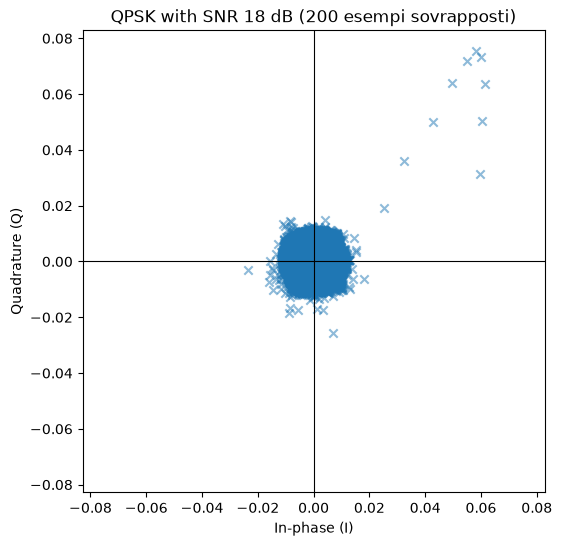

In [106]:
keys = data.keys()
mods, snrs = zip(*keys)
unique_mods = np.unique(mods)   # sorted numpy array of strings
unique_snrs = np.unique(snrs)   # sorted numpy array of ints

# unique_mods: '8PSK' 'AM-DSB' 'AM-SSB' 'BPSK' 'CPFSK' 'GFSK' 'PAM4' 'QAM16' 'QAM64''QPSK' 'WBFM'
mod = 'QPSK'
snr = 18
num_examples = 200   

examples = data[(mod, snr)][:num_examples]   # shape (num_examples, 2, 128)
I = examples[:, 0, :]   # shape (num_examples, 128)
Q = examples[:, 1, :]   # shape (num_examples, 128)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(I, Q, marker='x', alpha=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

limit = np.max(np.abs([I, Q])) * 1.1
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal', adjustable='box')

ax.set_title(f'{mod} with SNR {snr} dB ({num_examples} esempi sovrapposti)')
ax.set_xlabel('In-phase (I)')
ax.set_ylabel('Quadrature (Q)')
plt.show()

### Downsampling to the Simbol Rate
 The samples are raw, not matched with the pulses for each modulation. This way the Constellation plots found aren't alligned with the theory, we need to downsample to find clusters of stars in the desired areas.

 I found online tha GNU Radio often oversamples at 8 samples per simbol

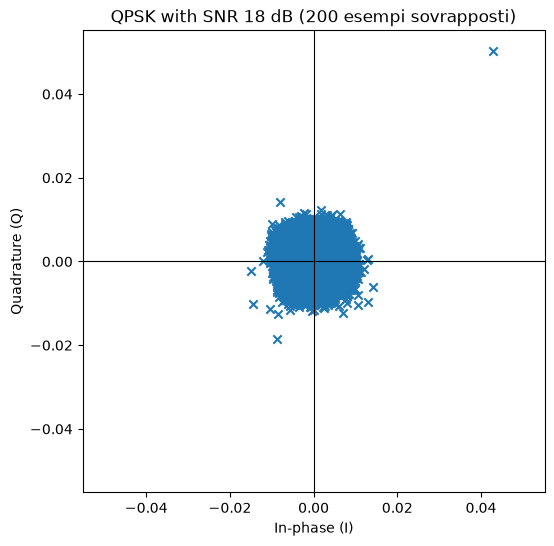

In [107]:
oversample_coeff = 8
offset = 8
I_sym = I[:, offset::oversample_coeff]   # shape (num_examples, n_simboli)
Q_sym = Q[:, offset::oversample_coeff]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(I_sym, Q_sym, marker='x', alpha=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

limit = np.max(np.abs([I_sym, Q_sym])) * 1.1
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal', adjustable='box')

ax.set_title(f'{mod} with SNR {snr} dB ({num_examples} esempi sovrapposti)')
ax.set_xlabel('In-phase (I)')
ax.set_ylabel('Quadrature (Q)')
plt.show()

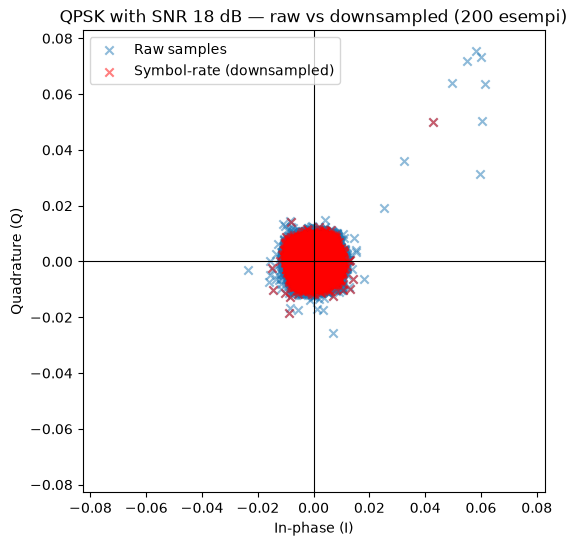

In [108]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(I, Q, marker='x', alpha=0.5, color='tab:blue', label='Raw samples')
ax.scatter(I_sym, Q_sym, marker='x', alpha=0.5, color='red', label='Symbol-rate (downsampled)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

limit = np.max(np.abs([I, Q])) * 1.1
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal', adjustable='box')

ax.set_title(f'{mod} with SNR {snr} dB — raw vs downsampled ({num_examples} esempi)')
ax.set_xlabel('In-phase (I)')
ax.set_ylabel('Quadrature (Q)')
ax.legend()
plt.show()

### Mueller & Muller Timing Recovery
Il naive downsampling assume un `offset` fisso valido per l'intero esempio. In realtà il clock offset introdotto dal dataset può far "derivare" leggermente il punto di campionamento ottimale.

L'algoritmo di Mueller & Muller è un loop di sincronizzazione a catena chiusa: per ogni simbolo stima l'errore di timing confrontando il campione corrente, quello precedente e la loro versione "decisa" (sign), poi corregge l'istante di campionamento successivo di conseguenza. Qui lo applichiamo a un singolo esempio (l'algoritmo lavora su uno stream continuo, non su batch).

In [ ]:
def mueller_muller(samples, oversample_coeff, mu_gain):
    """Ritorna i simboli recuperati (array complesso) da uno stream campionato."""
    out = []
    out_rail = [0j, 0j]   # storia delle ultime due decisioni "hard" (sign)

    mu = 0.0    # offset frazionario stimato all'interno del periodo di simbolo
    i_in = 0    # indice nel segnale di ingresso

    while i_in + oversample_coeff < len(samples):
        sample = samples[i_in]
        rail = np.sign(sample.real) + 1j * np.sign(sample.imag)

        if len(out) >= 2:
            # timing error detector di Mueller & Muller
            x = (rail - out_rail[-2]) * np.conj(out[-1])
            y = (sample - out[-2]) * np.conj(out_rail[-1])
            mm_error = (y - x).real
        else:
            mm_error = 0.0   # non abbastanza storia ancora per stimare l'errore

        out.append(sample)
        out_rail.append(rail)

        mu += oversample_coeff + mu_gain * mm_error
        i_in += int(np.floor(mu))
        mu -= np.floor(mu)

    return np.array(out[2:])   # scarta i due campioni di "storia" iniziali


mu_gain = 0.05   # step size del loop: piu' alto = insegue piu' veloce ma piu' rumoroso

# applichiamo M&M a ciascuno dei num_examples esempi (l'algoritmo lavora su uno
# stream continuo alla volta) e concateniamo i simboli recuperati, per essere
# comparabili in quantita' con raw samples e naive downsampling
mm_symbols = []
for raw_example in data[(mod, snr)][:num_examples]:
    ex_samples = raw_example[0] + 1j * raw_example[1]   # segnale complesso I + jQ
    ex_samples = ex_samples[1:]   # scartiamo il primo campione: artefatto del transitorio di pulse-shaping
    ex_samples = ex_samples / np.sqrt(np.mean(np.abs(ex_samples) ** 2))   # normalizzazione a potenza unitaria (AGC)
    mm_symbols.append(mueller_muller(ex_samples, oversample_coeff, mu_gain))

mm_symbols = np.concatenate(mm_symbols)
I_mm, Q_mm = mm_symbols.real, mm_symbols.imag

# raw samples normalizzati esempio per esempio, per essere sulla stessa scala di M&M
raw_examples = data[(mod, snr)][:num_examples]
raw_complex = raw_examples[:, 0, :] + 1j * raw_examples[:, 1, :]   # shape (num_examples, 128)
raw_complex = raw_complex[:, 1:]
raw_rms = np.sqrt(np.mean(np.abs(raw_complex) ** 2, axis=1, keepdims=True))
raw_complex = raw_complex / raw_rms
I_raw_norm, Q_raw_norm = raw_complex.real, raw_complex.imag

# normalizziamo anche il naive downsampling con lo stesso criterio, per restare
# comparabile in scala con raw samples e M&M nello stesso plot
naive_rms = np.sqrt(np.mean(I_sym ** 2 + Q_sym ** 2))
I_sym_norm = I_sym / naive_rms
Q_sym_norm = Q_sym / naive_rms

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(I_raw_norm, Q_raw_norm, marker='x', alpha=0.5, color='tab:blue', label='Raw samples')
ax.scatter(I_sym_norm, Q_sym_norm, marker='x', alpha=0.5, color='red', label='Naive downsampling')
ax.scatter(I_mm, Q_mm, marker='o', alpha=0.5, color='green', label='Mueller & Muller')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

limit = np.max(np.abs([I_raw_norm, Q_raw_norm])) * 1.1
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect('equal', adjustable='box')

ax.set_title(f'{mod} with SNR {snr} dB — Mueller & Muller (mu_gain={mu_gain})')
ax.set_xlabel('In-phase (I)')
ax.set_ylabel('Quadrature (Q)')
ax.legend()
plt.show()

## 3. Build X, y, and SNR arrays from the dictionary

## 4. Train / validation / test split

## 5. PyTorch Dataset and DataLoader

## 6. Model: 1D CNN

## 7. Training loop

## 8. Evaluation